In [4]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import skopi as sk

import torch
from tqdm import tqdm 
import time
import h5py

from neurorient import uniform_points_on_sphere
from neurorient.reconstruction.slicing import get_real_mesh

import os
os.environ["USE_CUPY"] = "1"
os.environ.get('USE_CUPY')

'1'

In [5]:
save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/data/dragonfly_data_Newton_R1'

In [6]:
pdb = '1BXR'
increase_factor = 1
poisson = False
num_images = 10000

In [7]:

# n_pixels, det_size, det_dist = (150, 0.0768, 0.15)
n_pixels = 300
pixel_size = 0.512 / 2 * 1e-3
det_size = pixel_size * n_pixels
det_dist = 0.15

# Set up x-ray beam
beam = sk.Beam("input/beam/dragonfly.beam")
beam.set_photons_per_pulse(increase_factor * beam.get_photons_per_pulse())

det = sk.SimpleSquareDetector(n_pixels, det_size, det_dist, beam=beam)

In [9]:
import os

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [10]:
with h5py.File('input/dragonfly/det_sim_Newton_R1_300x300.h5', "r") as f:
    print(f.keys())

    det_dragonfly_reference = {}
    
    for k, v in f.items():
        if v.shape == ():
            det_dragonfly_reference[k] = v[()]
        else:
            print(k, v.shape)
            det_dragonfly_reference[k] = v[:]


<KeysViewHDF5 ['corr', 'detd', 'ewald_rad', 'mask', 'qx', 'qy', 'qz']>
corr (90000,)
mask (90000,)
qx (90000,)
qy (90000,)
qz (90000,)


In [18]:
det.pixel_distance_reciprocal.max()

array(1.27838471e+09)

In [ ]:
np.linalg.norm(np.concatenate([
    det_dragonfly_reference['qx'][...,None], 
    det_dragonfly_reference['qy'][...,None],
    det_dragonfly_reference['qz'][...,None]
], axis=-1), axis=-1).max() * 1e7

array(1.57928413)

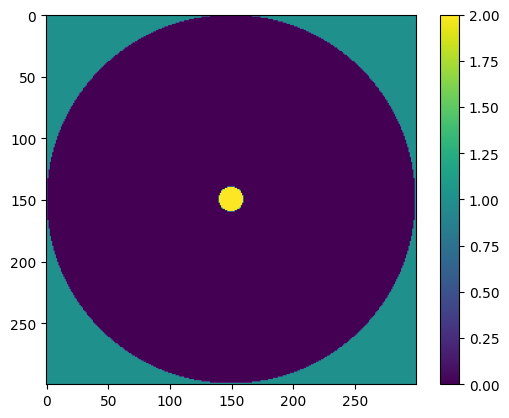

In [9]:
plt.imshow(
    det_dragonfly_reference['mask'].reshape(n_pixels, n_pixels, order='F'),
)
plt.colorbar()

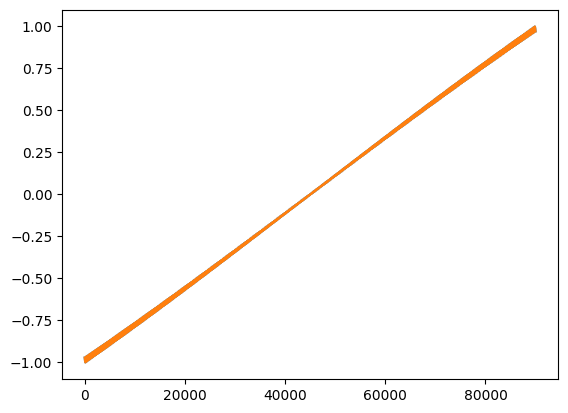

In [10]:
plt.plot(det_dragonfly_reference['qx'] / det_dragonfly_reference['qx'].max())
plt.plot(det.pixel_position_reciprocal[0,...,0].get().reshape(-1, order='F') / \
         det.pixel_position_reciprocal[0,...,0].get().max())

In [11]:
det_dragonfly_reference['corr'].mean()

2.6802966247437432e-06

In [12]:
det_dragonfly_reference_pix_pos_reciprocal = np.stack([
    det_dragonfly_reference['qx'],
    det_dragonfly_reference['qy'],
    det_dragonfly_reference['qz']
], axis=-1)

det_dragonfly_reference_pix_pos_reciprocal.shape

(90000, 3)

In [16]:
det_corr_multi_factor = 1e-5
det_pix_pos_multi_factor = 1e-7

In [17]:
qx_final = det.pixel_position_reciprocal[0, ..., 0].get().reshape(-1, order='F') * det_pix_pos_multi_factor
qy_final = det.pixel_position_reciprocal[0, ..., 1].get().reshape(-1, order='F') * det_pix_pos_multi_factor
qz_final = det.pixel_position_reciprocal[0, ..., 2].get().reshape(-1, order='F') * det_pix_pos_multi_factor

print(qx_final.max(), qy_final.max(), qz_final.max())
print(qx_final.shape, qy_final.shape, qz_final.shape)

91.72465590647842 91.72465590647842 -0.00027016460081749177
(90000,) (90000,) (90000,)


In [18]:
detd_pix_final = det_dist / (det_size / n_pixels)
ewald_rad_final = detd_pix_final

print(detd_pix_final, ewald_rad_final)

585.9375 585.9375


In [19]:
corr_final = det.polarization_correction.get().reshape(-1, order='F') * det_corr_multi_factor

print(det_dragonfly_reference['corr'].mean() / corr_final.mean())

0.27366672249884577


In [20]:
mask_final = det_dragonfly_reference['mask']

In [21]:
det_final = {
    'qx': qx_final,
    'qy': qy_final,
    'qz': qz_final,
    'mask': mask_final,
    'corr': corr_final,
    'detd': detd_pix_final,
    'ewald_rad': ewald_rad_final
}

In [22]:
print(det_final.keys(), '\n', det_dragonfly_reference.keys())

dict_keys(['qx', 'qy', 'qz', 'mask', 'corr', 'detd', 'ewald_rad']) 
 dict_keys(['corr', 'detd', 'ewald_rad', 'mask', 'qx', 'qy', 'qz'])


In [24]:
h5_fpath = os.path.join(
    save_dir, 
    f'det_sim_Newton_R1_{n_pixels}x{n_pixels}.h5')
print("data will be saved to: \n", h5_fpath)
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('qx', data=det_final['qx'])
    f.create_dataset('qy', data=det_final['qy'])
    f.create_dataset('qz', data=det_final['qz'])
    f.create_dataset('mask', data=det_final['mask'])
    f.create_dataset('corr', data=det_final['corr'])
    f.create_dataset('detd', data=det_final['detd'])
    f.create_dataset('ewald_rad', data=det_final['ewald_rad'])

data will be saved to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/dragonfly_data_Newton_R1/det_sim_Newton_R1_300x300.h5
